In [1]:
import os

BASE_DIR = "ABSOLUTE_PATH_TO_THE_ROOT"
DATA_DIR = os.path.join(BASE_DIR, "data")
CODE_DIR = os.path.join(BASE_DIR, "code")
FC_DIR = os.path.join(BASE_DIR, 'models_save/fc')
UC_DIR = os.path.join(BASE_DIR, 'models_save/uc')

import sys

sys.path.append(CODE_DIR)

In [ ]:
import os
import json

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, KernelPCA
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from matplotlib import pyplot as plt

from models.uncertainty.dist_match.tree import DistMatchQRF, DistMatchTree
from models.uncertainty.dist_match.utils import match_ks_stat

from sklearn_quantile import RandomForestQuantileRegressor

from matplotlib import pyplot as plt, rcParams, rc
from scipy.stats import ks_2samp, norm, expon

In [ ]:
ROOT_PATH = 'ABSOLUTE_PATH_TO_PROJECT_ROOT'

In [3]:
rcParams["font.weight"] = "bold"
rcParams['text.latex.preamble']=r"\boldmath"

In [4]:
def matcher(x1, x2):
    return match_ks_stat(x1, x2) <= 0.8

In [6]:
# tree_path = "/data5/users/enver/projects/conformal/dist_bench/models_save/uc/qrf_ks_windWind_Hackberry_Generation_2019_2020.pkl"
# tree_path = "/data/enver/projects/dist_bench/models_save/uc/qrf_kl_solarSolar_Atl_data_aligned.pkl"
tree_path = "/data8/enver/projects/conformal/dist_bench/models_save/uc/qrf_ks_stat_error_normal_electricelectricity-normalized_darts-forest|100.pkl"
qrf = DistMatchQRF(
    alpha=0.1,
    n_quantile_bins=10,
    feature_dim=-1,
    matcher=matcher,
    match_mask=None,
    n_trees=10,
    bagging_ratio=0.9,
    verbose=False,
)
qrf.load_trees(tree_path)

In [7]:
def get_elec_file_dir(data_key: str):
    return f"/data8/enver/projects/conformal/dist_bench/outputs/{data_key}/wandb/latest-run/files/media/table/Eval_electricelectricity-normalized_plots"


def read_json(path: str):
    with open(path, "r") as file:
        data = json.load(file)
    cols = data["columns"]
    data = data["data"]
    data = [dict(zip(cols, datum)) for datum in data]
    return pd.DataFrame.from_records(data)

In [46]:
key = "darts_forest_dist_match_enbPI_electric_s30_160126_163750"

file_dir = get_elec_file_dir(key)
filename = os.listdir(file_dir)[0]

result_df = read_json(os.path.join(file_dir, filename))

In [47]:
def get_cdf(_data):
    data_sorted = np.sort(_data)
    cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
    return data_sorted, cdf

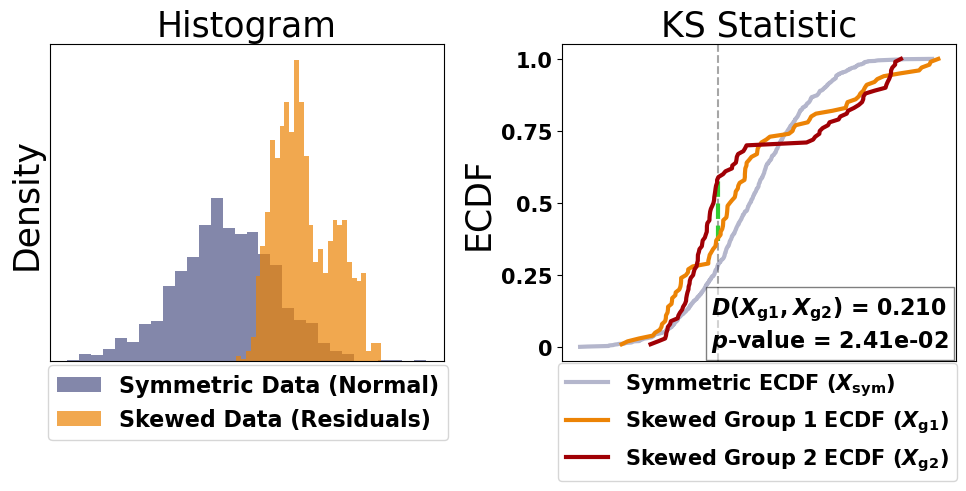

In [79]:
# Generate symmetric and skewed data
np.random.seed(1)
symmetric_data = np.random.normal(loc=0, scale=0.3, size=1000)
skewed_data = result_df["y_real"].values
# skewed_data = (skewed_data - skewed_data.min()) / (skewed_data.max() - skewed_data.min())
# skewed_data = (skewed_data - skewed_data.mean()) / skewed_data.std()

# Redraw the plot with a filled region for the D-statistic
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

color1 = "#091057"  # EFB036 3B6790
color2 = "#EC8305"
color3 = "#A00005"

# Plot histograms on the left
axs[0].hist(
    symmetric_data,
    bins=30,
    alpha=0.5,
    label="Symmetric Data (Normal)",
    density=True,
    color=color1,
)
axs[0].hist(
    skewed_data,
    bins=30,
    alpha=0.7,
    label="Skewed Data (Residuals)",
    density=True,
    color=color2,
)
axs[0].set_title("Histogram", fontsize=25)
# axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density", fontsize=25)
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].legend(fontsize=16, bbox_to_anchor=(1.04, 0.022))

leaf_nodes = qrf.trees[0].leaf_nodes

skewed_data1 = leaf_nodes[12].get_values()[0][0].ravel()
skewed_data2 = leaf_nodes[11].get_values()[0][0].ravel()

skewed_data1 = (skewed_data1 - skewed_data1.mean()) / skewed_data1.std()
skewed_data2 = (skewed_data2 - skewed_data2.mean()) / skewed_data2.std()

symmetric_data = np.random.normal(loc=0, scale=0.7, size=1000)


# KS test
ks_sym, ks_sym_p = ks_2samp(symmetric_data, skewed_data)
ks_skew, ks_skew_p = ks_2samp(skewed_data1, skewed_data2)


# Calculate CDFs
symmetric_data_sorted, sym_cdf = get_cdf(symmetric_data)
skewed_data1_sorted, skew_cdf1 = get_cdf(skewed_data1)
skewed_data2_sorted, skew_cdf2 = get_cdf(skewed_data2)

# Plot CDFs on the right
line_pos = -0.4
axs[1].axvline(x=line_pos, color="gray", linestyle="--", alpha=0.7)

line_ymin = skew_cdf1[abs(skewed_data1_sorted - line_pos).argmin()]
line_ymax = skew_cdf2[abs(skewed_data2_sorted - line_pos).argmin() - 1]

axs[1].axvline(
    x=line_pos,
    ymin=line_ymin,
    ymax=line_ymax,
    color="#32CD32",
    linestyle="--",
    linewidth=3,
)
axs[1].plot(
    symmetric_data_sorted,
    sym_cdf,
    label=r"Symmetric ECDF ($X_\text{sym}$)",
    linewidth=3,
    alpha=0.3,
    color=color1,
)
axs[1].plot(
    skewed_data1_sorted,
    skew_cdf1,
    label=r"Skewed Group 1 ECDF ($X_\text{g1}$)",
    linewidth=3,
    color=color2,
)
axs[1].plot(
    skewed_data2_sorted,
    skew_cdf2,
    label=r"Skewed Group 2 ECDF ($X_\text{g2}$)",
    linewidth=3,
    color=color3,
)
axs[1].text(
    -0.49,
    -0.0,
    r"$\boldsymbol{D}(X_\text{g1}, X_\text{g2})$"
    + f" = {ks_skew:.3f}\n$p$-value = {ks_skew_p:.2e}",
    bbox=dict(facecolor="white", alpha=0.5),
    fontsize=16,
)
# axs[1].text(
#     -0.35,
#     0.09,
#     r"$D(X_\text{sym}, X_{g1, g2})$"
#     + f" = {ks_sym:.3f}\n$p$-value = {ks_sym_p:.2e}",
#     bbox=dict(facecolor="white", alpha=0.5),
#     fontsize=13,
# )

# Highlight the D-statistic with fill_between

# Customize CDF plot
axs[1].set_title("KS Statistic", fontsize=25)
# axs[1].set_xlabel('Value', fontsize=30)
axs[1].set_xticks([])
axs[1].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
axs[1].set_yticklabels(labels=[0, 0.25, 0.5, 0.75, 1.0], fontsize=15)
axs[1].set_ylabel("ECDF", fontsize=25)
axs[1].legend(fontsize=15, bbox_to_anchor=(1.028, 0.027))

# Remove grid from both plots
for ax in axs:
    ax.grid(False)

# Adjust layout and show the plot
plt.tight_layout()
plt.savefig('./ks_test_residuals.pdf')
plt.show()